# Heat-Pump / IHB LCOH Screen — Verification & Visualization

**Purpose:** sanity-check the technology + cost + land screen produced by
`run_hp_ihb_lcoh_screen.py`, which replaces the hourly optimizer.

**Method (paper-style, on-site solar powers everything):** each facility's replaceable heat is
split into temperature bands; each band is assigned a technology and an LCOH rebuilt on solar:

| band | technology | COP |
|---|---|---|
| < 100 °C | low-temperature heat pump | 2.7 |
| 100–200 °C | steam heat pump | 1.8 |
| > 200 °C | IHB / thermal battery (resistive) | 1.0 |

Green LCOH is the heat-weighted average of the band LCOHs, compared to the country gas
benchmark. The **land screen** sizes PV per band (heat pumps need less via COP), converts to
land at 50 MWdc/km², and credits each facility's locally-matchable heat fraction.


## System configuration — two temperature-split chains per facility

Each facility runs **one shared on-site solar array** feeding **two independent technology
chains**, split by temperature. The heat pump (efficient but temperature-limited) serves the
low-temp bands; a resistive heater (any temperature, but COP 1.0) serves the high-temp bands.
Both charge a thermal battery that buffers intermittent solar into continuous 24/7 process heat.

```
                          ┌─────────────────────────────────────────────┐
   On-site solar PV ──────┤                                             │
     (shared array)       │   LOW-TEMP  (< 200 °C)                      │
                          │   HEAT PUMP  ──▶  warm heat battery  ──▶  process  (< 200 °C)
                          │   COP 2.7 / 1.8   (16 h storage)            │
                          │                                             │
                          │   HIGH-TEMP  (> 200 °C)                     │
                          │   RESISTIVE  ──▶  hot heat battery   ──▶  process  (> 200 °C)
                          │   COP 1.0         (16 h storage, ≤1500 °C)  │
                          └─────────────────────────────────────────────┘
```

**A heat pump cannot reach > 200 °C, so it never feeds the hot battery** — high-temp heat comes
from the resistive element instead. The two chains share only the solar array; they have separate
converters and separate stores. Each facility uses whichever chains its temperature bands require
(a food plant is ~85 % heat pump; a cement plant is ~95 % resistive/IHB).

| | heat pump | resistive (IHB) |
|---|---|---|
| efficiency (COP) | 2.7 / 1.8 → needs ⅓–½ the solar | 1.0 → needs the most solar |
| max temperature | ~200 °C | ~1500 °C |

*Real-world basis:* resistive + thermal battery is commercializing (Rondo, Antora, Brenmiller);
heat pump + thermal storage is established in lower-temperature industry and district heating. The
temperature-split combination here is a portfolio construct, matching the manuscript's method
(heat pumps < 200 °C, direct-electric + thermal battery > 200 °C, every block paired with 16 h storage).

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd()
while not (ROOT / "run_hp_ihb_lcoh_screen.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
df = pd.read_csv(ROOT / "outputs" / "hp_ihb_lcoh_by_facility.csv")

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E6E6E6", "grid.linewidth": 0.8,
    "axes.edgecolor": "#888", "xtick.color": "#444", "ytick.color": "#444",
})
SEQ = "cividis"
GREEN, RED, BLUE, ORANGE, MUTED, INK = "#009E73", "#D55E00", "#0072B2", "#E69F00", "#666", "#222"

w = df["replaceable_heat_mwh_th"]; tot = w.sum()
print(f"sites: {len(df)}   total replaceable heat: {tot/1e6:.1f} TWh")
print(f"heat-weighted green LCOH: {(df['green_lcoh_eur_mwh']*w).sum()/tot:.1f} EUR/MWh  |  "
      f"gas benchmark: {(df['gas_benchmark_eur_mwh']*w).sum()/tot:.1f}")
df.head(3)


sites: 2192   total replaceable heat: 522.3 TWh
heat-weighted green LCOH: 71.8 EUR/MWh  |  gas benchmark: 77.6


,source_id,source_name,iso3_country,subsector,replaceable_heat_mwh_th,available_land_km2,solar_capacity_factor,green_lcoh_eur_mwh,gas_benchmark_eur_mwh,lcoh_ratio_vs_gas,...,hp_heat_share,ihb_heat_share,pv_required_mwdc,land_required_km2,local_fit_fraction,land_matched_heat_mwh,green_and_local_heat_mwh,low_temp_hp_solar,steam_hp_solar,ihb_solar
0,38480613,Agrana Zucker Gmbh,AUT,food-beverage-tobacco,415349.825748,43.270023,0.158751,64.094899,81.362353,0.787771,...,0.835452,0.164548,169.398236,3.387965,1.000000,415349.825748,415349.825748,53.349436,71.024155,81.043478
1,38480620,Agrana Zucker Gmbh,AUT,food-beverage-tobacco,415349.825748,36.454533,0.157044,64.094899,81.362353,0.787771,...,0.835452,0.164548,171.239208,3.424784,1.000000,415349.825748,415349.825748,53.349436,71.024155,81.043478
2,32267416,Austria,AUT,chemicals,286371.874095,0.103403,0.157748,68.727536,81.362353,0.844709,...,0.700000,0.300000,138.156747,2.763135,0.037422,10716.694317,10716.694317,53.349436,71.024155,81.043478


## 1. The headline screen — cost, land, and both

How much of the 522 TWh of replaceable heat is (a) below the gas benchmark on cost, (b) locally land-matchable, and (c) both. The combined bar is the deployable opportunity.

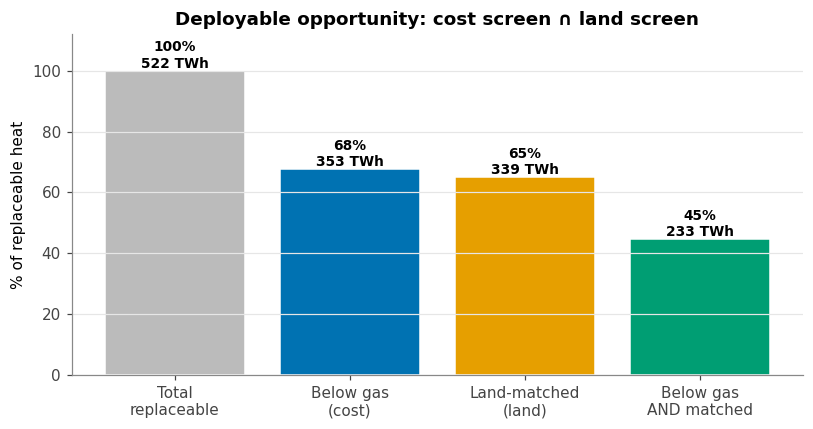

In [2]:
cost = w[df["below_gas"]].sum()/tot*100
land = df["land_matched_heat_mwh"].sum()/tot*100
both = df["green_and_local_heat_mwh"].sum()/tot*100

fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(["Total\nreplaceable", "Below gas\n(cost)", "Land-matched\n(land)", "Below gas\nAND matched"],
              [100, cost, land, both], color=["#BBBBBB", BLUE, ORANGE, GREEN], edgecolor="white")
for b, v in zip(bars, [100, cost, land, both]):
    ax.annotate(f"{v:.0f}%\n{v/100*tot/1e6:.0f} TWh", (b.get_x()+b.get_width()/2, v),
                ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("% of replaceable heat"); ax.set_ylim(0, 112)
ax.set_title("Deployable opportunity: cost screen ∩ land screen"); ax.grid(False, axis="x")
plt.tight_layout(); plt.show()


## 2. Green LCOH distribution vs the gas benchmark

Where each facility's green heat cost lands relative to its country gas benchmark. Sites left of parity are cost-competitive.

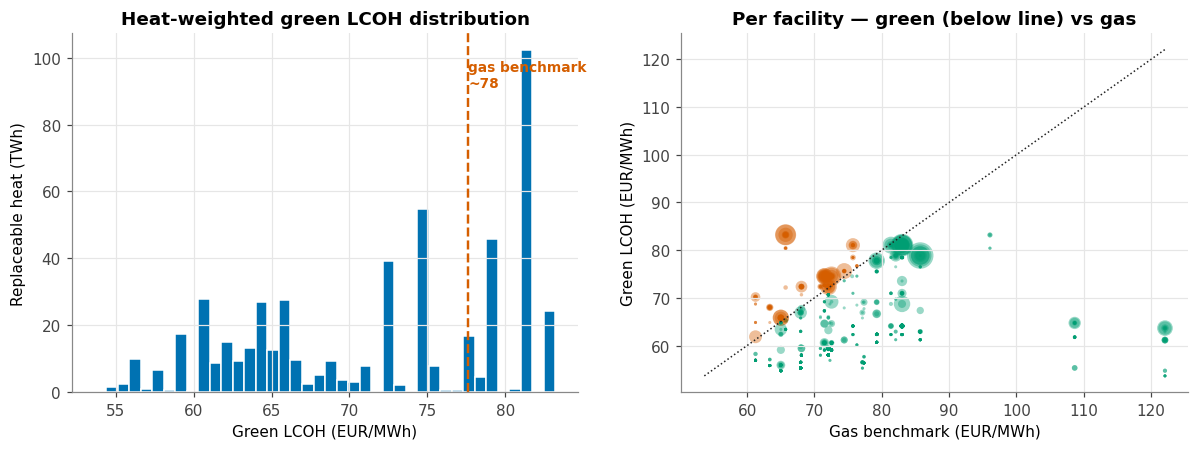

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(df["green_lcoh_eur_mwh"], bins=40, color=BLUE, edgecolor="white", weights=w/1e6)
gw = (df["gas_benchmark_eur_mwh"]*w).sum()/tot
axes[0].axvline(gw, color=RED, ls="--", lw=1.6)
axes[0].annotate(f"gas benchmark\n~{gw:.0f}", (gw, axes[0].get_ylim()[1]*0.85), color=RED,
                 fontsize=9, fontweight="bold")
axes[0].set_xlabel("Green LCOH (EUR/MWh)"); axes[0].set_ylabel("Replaceable heat (TWh)")
axes[0].set_title("Heat-weighted green LCOH distribution")

axes[1].scatter(df["gas_benchmark_eur_mwh"], df["green_lcoh_eur_mwh"],
                s=np.clip(w/w.max()*300, 4, 300), alpha=0.4,
                c=np.where(df["below_gas"], GREEN, RED), edgecolor="none")
lim = [df[["gas_benchmark_eur_mwh","green_lcoh_eur_mwh"]].min().min(),
       df[["gas_benchmark_eur_mwh","green_lcoh_eur_mwh"]].max().max()]
axes[1].plot(lim, lim, color=INK, lw=1, ls=":")
axes[1].set_xlabel("Gas benchmark (EUR/MWh)"); axes[1].set_ylabel("Green LCOH (EUR/MWh)")
axes[1].set_title("Per facility — green (below line) vs gas")
plt.tight_layout(); plt.show()


## 3. The three screens by subsector

Below-gas (cost), land-matched (land), and both. The gap between land-matched and both for high-temp sectors, and between below-gas and both for low-temp sectors, tells the story.

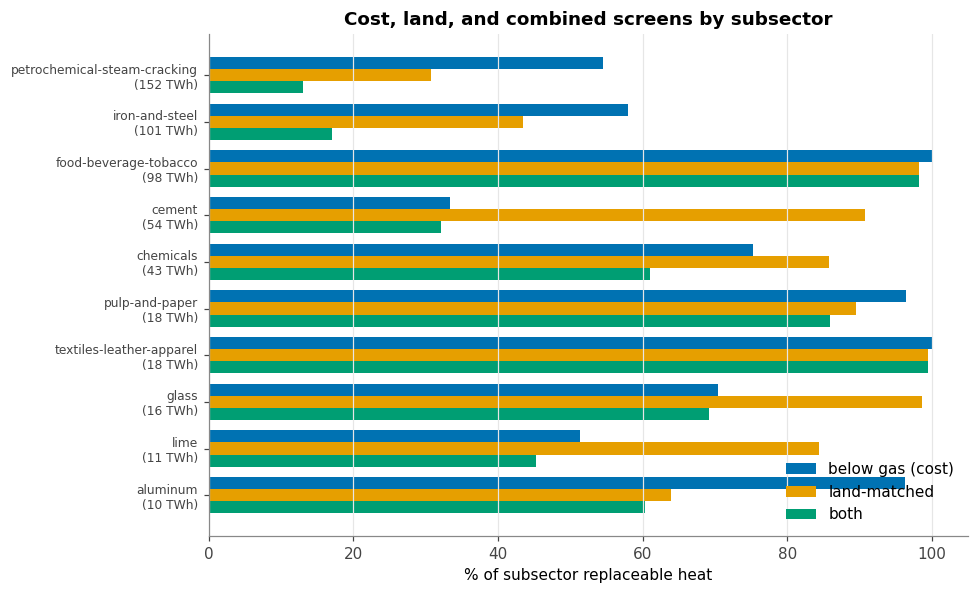

In [4]:
g = df.groupby("subsector").apply(lambda x: pd.Series({
    "heat_TWh": x["replaceable_heat_mwh_th"].sum()/1e6,
    "below_gas": x.loc[x["below_gas"],"replaceable_heat_mwh_th"].sum()/x["replaceable_heat_mwh_th"].sum()*100,
    "land": x["land_matched_heat_mwh"].sum()/x["replaceable_heat_mwh_th"].sum()*100,
    "both": x["green_and_local_heat_mwh"].sum()/x["replaceable_heat_mwh_th"].sum()*100,
}), include_groups=False).sort_values("heat_TWh")

fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(g)); h = 0.26
ax.barh(y+h, g["below_gas"], h, color=BLUE, label="below gas (cost)")
ax.barh(y, g["land"], h, color=ORANGE, label="land-matched")
ax.barh(y-h, g["both"], h, color=GREEN, label="both")
ax.set_yticks(y); ax.set_yticklabels([f"{s}\n({t:.0f} TWh)" for s,t in zip(g.index, g["heat_TWh"])], fontsize=8)
ax.set_xlabel("% of subsector replaceable heat"); ax.set_title("Cost, land, and combined screens by subsector")
ax.legend(frameon=False, loc="lower right"); ax.grid(False, axis="y")
plt.tight_layout(); plt.show()


## 4. Technology split — heat pump vs IHB

Share of each subsector's heat served by heat pumps (<200 °C) vs the IHB (>200 °C). Heat-pump-heavy sectors get cheap, low-PV heat; IHB-heavy sectors drive land and cost.

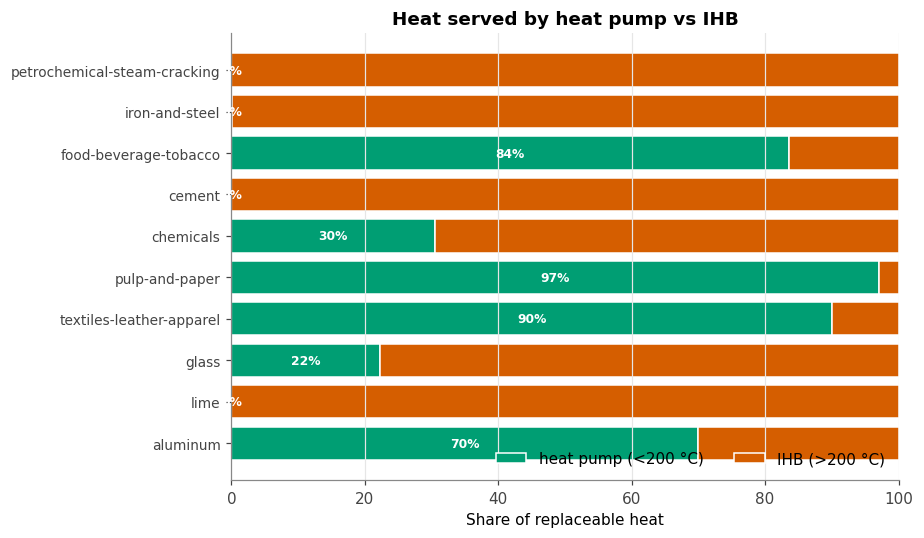

In [5]:
hp = df.groupby("subsector").apply(
    lambda x: (x["hp_heat_share"]*x["replaceable_heat_mwh_th"]).sum()/x["replaceable_heat_mwh_th"].sum(),
    include_groups=False).reindex(g.index)*100
fig, ax = plt.subplots(figsize=(8.5, 5))
y = np.arange(len(g))
ax.barh(y, hp, color=GREEN, edgecolor="white", label="heat pump (<200 °C)")
ax.barh(y, 100-hp, left=hp, color=RED, edgecolor="white", label="IHB (>200 °C)")
ax.set_yticks(y); ax.set_yticklabels(g.index, fontsize=9)
for i, v in enumerate(hp):
    ax.annotate(f"{v:.0f}%", (v/2, i), ha="center", va="center", color="white", fontsize=8, fontweight="bold")
ax.set_xlabel("Share of replaceable heat"); ax.set_title("Heat served by heat pump vs IHB")
ax.legend(frameon=False, loc="lower right", ncol=2); ax.grid(False, axis="y"); ax.set_xlim(0,100)
plt.tight_layout(); plt.show()


## 5. Land requirement — the COP dividend

PV (and land) required scales inversely with COP, so heat-pump-heavy sites need far less land per MWh. Left: local-fit fraction distribution. Right: required vs available land.

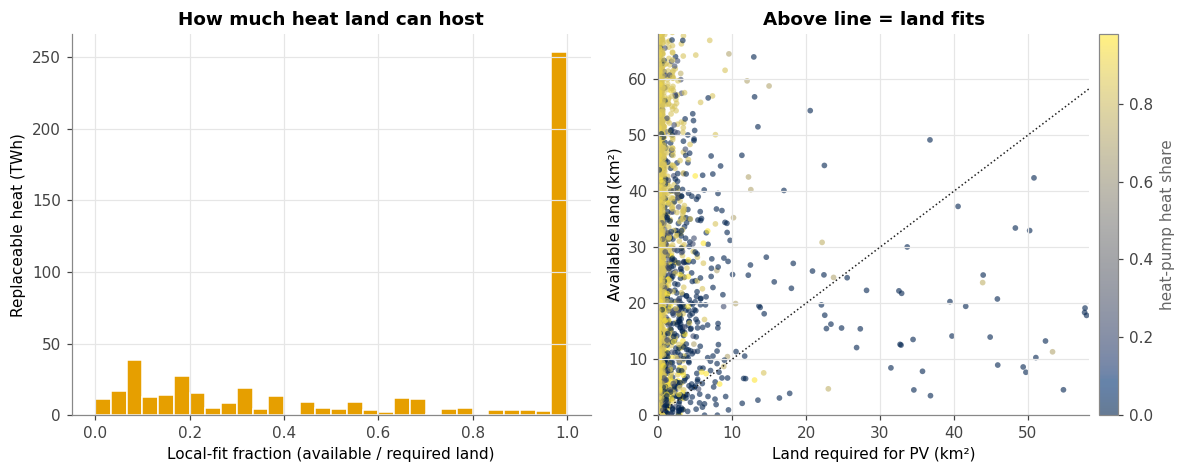

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].hist(df["local_fit_fraction"], bins=30, color=ORANGE, edgecolor="white", weights=w/1e6)
axes[0].set_xlabel("Local-fit fraction (available / required land)")
axes[0].set_ylabel("Replaceable heat (TWh)"); axes[0].set_title("How much heat land can host")

sc = axes[1].scatter(df["land_required_km2"], df["available_land_km2"],
                     c=df["hp_heat_share"], cmap=SEQ, s=14, alpha=0.6, edgecolor="none")
mx = np.nanpercentile(df["land_required_km2"], 99)
axes[1].plot([0, mx], [0, mx], color=INK, lw=1, ls=":")
axes[1].set_xlim(0, mx); axes[1].set_ylim(0, np.nanpercentile(df["available_land_km2"],99))
axes[1].set_xlabel("Land required for PV (km²)"); axes[1].set_ylabel("Available land (km²)")
axes[1].set_title("Above line = land fits")
cb = fig.colorbar(sc, ax=axes[1], pad=0.02); cb.set_label("heat-pump heat share", color=MUTED)
plt.tight_layout(); plt.show()


## 6. By country

Green LCOH and combined (below-gas AND land-matched) share by country — dominated by electricity/gas price and solar resource.

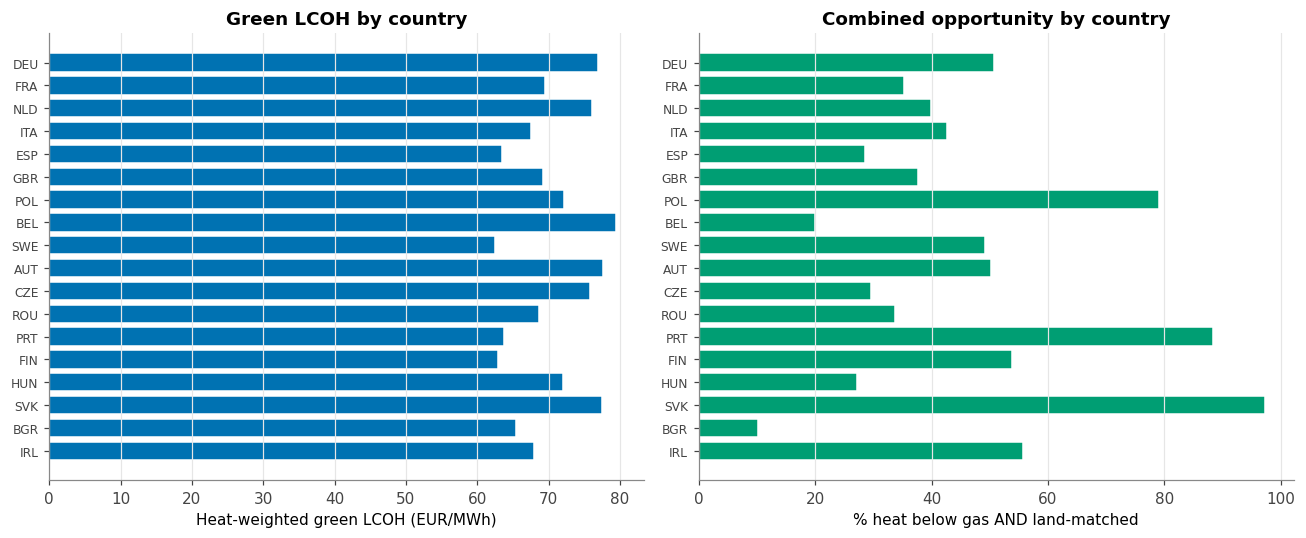

In [7]:
gc = df.groupby("iso3_country").apply(lambda x: pd.Series({
    "heat_TWh": x["replaceable_heat_mwh_th"].sum()/1e6,
    "green_lcoh": (x["green_lcoh_eur_mwh"]*x["replaceable_heat_mwh_th"]).sum()/x["replaceable_heat_mwh_th"].sum(),
    "both": x["green_and_local_heat_mwh"].sum()/x["replaceable_heat_mwh_th"].sum()*100,
}), include_groups=False).sort_values("heat_TWh", ascending=False).head(18)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
yc = np.arange(len(gc))[::-1]
axes[0].barh(yc, gc["green_lcoh"], color=BLUE, edgecolor="white")
axes[0].set_yticks(yc); axes[0].set_yticklabels(gc.index, fontsize=8)
axes[0].set_xlabel("Heat-weighted green LCOH (EUR/MWh)"); axes[0].set_title("Green LCOH by country"); axes[0].grid(False, axis="y")
axes[1].barh(yc, gc["both"], color=GREEN, edgecolor="white")
axes[1].set_yticks(yc); axes[1].set_yticklabels(gc.index, fontsize=8)
axes[1].set_xlabel("% heat below gas AND land-matched"); axes[1].set_title("Combined opportunity by country"); axes[1].grid(False, axis="y")
plt.tight_layout(); plt.show()


## 7. Verification summary

- **Headline** — of 522 TWh replaceable heat: ~67% below gas (cost), ~65% land-matched, ~45% both.
- **Technology** — heat pumps serve the <200 °C bands (25% of heat) cheaply and with little PV;
  the IHB serves >200 °C (75%) at higher PV/land cost.
- **Low-temp sectors** (food, textiles, pulp) — nearly all heat is both below gas and land-matched.
- **High-temp sectors** (petrochem, steel) — cost-competitive but land-constrained (IHB PV footprint).
- **Caveats** — annual energy matching, not hourly dispatch; GBR proxied to IRL; single band midpoint
  temperatures; land is a screening estimate with overlapping 5 km circles not de-duplicated.
